In [1]:
import pandas as pd
import os
import random

# Write the folder name only once
data_folder = "vol_1_ma_1_bb_0_rsi_0"

# Choose how many tickers to use
# Set to None if you want all tickers
MAX_TICKERS = 20

# Make ticker selection reproducible
TICKER_SEED = 42

# Build paths from that
csv_path = os.path.join(data_folder, "labels.csv")

# Load csv
df = pd.read_csv(csv_path)

# Convert dates
df["start_date"] = pd.to_datetime(df["start_date"])
df["end_date"] = pd.to_datetime(df["end_date"])

# Use end_date as the observation date for splitting
df["date"] = df["end_date"]

# --------------------------------------------------
# LIMIT NUMBER OF TICKERS EARLY IN THE FILE
# --------------------------------------------------
all_tickers = sorted(df["ticker"].unique())
print(f"Total tickers available before filtering: {len(all_tickers)}")

if MAX_TICKERS is not None:
    if MAX_TICKERS > len(all_tickers):
        raise ValueError(
            f"MAX_TICKERS={MAX_TICKERS} is larger than the number of available tickers ({len(all_tickers)})."
        )

    rng = random.Random(TICKER_SEED)
    selected_tickers = rng.sample(all_tickers, MAX_TICKERS)
    selected_tickers = sorted(selected_tickers)

    df = df[df["ticker"].isin(selected_tickers)].copy()
    print(f"Using {len(selected_tickers)} tickers: {selected_tickers[:10]}{' ...' if len(selected_tickers) > 10 else ''}")

print(f"Rows after ticker filtering: {len(df)}")
print(df["ticker"].nunique(), "unique tickers remain")

print(df.head())
print(df.info())
print(df["label"].value_counts())

Total tickers available before filtering: 100
Using 20 tickers: ['ACN', 'ADBE', 'ANET', 'AXP', 'BA', 'BLK', 'CRM', 'CSCO', 'CVX', 'DHR'] ...
Rows after ticker filtering: 4981
20 unique tickers remain
                                            image_path ticker start_date  \
747  vol_1_ma_1_bb_0_rsi_0\ACN\ACN_2020-01-08_to_20...    ACN 2020-01-08   
748  vol_1_ma_1_bb_0_rsi_0\ACN\ACN_2020-01-15_to_20...    ACN 2020-01-15   
749  vol_1_ma_1_bb_0_rsi_0\ACN\ACN_2020-01-23_to_20...    ACN 2020-01-23   
750  vol_1_ma_1_bb_0_rsi_0\ACN\ACN_2020-01-30_to_20...    ACN 2020-01-30   
751  vol_1_ma_1_bb_0_rsi_0\ACN\ACN_2020-02-06_to_20...    ACN 2020-02-06   

      end_date  close_now  close_future  label       date  
747 2020-01-14     207.73        209.41      1 2020-01-14  
748 2020-01-22     209.41        207.96      0 2020-01-22  
749 2020-01-29     207.96        212.22      1 2020-01-29  
750 2020-02-05     212.22        211.99      0 2020-02-05  
751 2020-02-12     211.99        213.90    

Tjekker at Billederne eksistere og fjerner rækker hvor billeder ikke eksisterer

In [2]:
import os

df["file_exists"] = df["image_path"].apply(os.path.exists)

print(df["file_exists"].value_counts())

# Keep only rows where the image exists
df = df[df["file_exists"]].copy()

file_exists
True    4981
Name: count, dtype: int64


Sorterer data efter tid, så rækker der tilhører samme Ticker/firma ikke længere kommer efter hinanden. Det er fordi man i Finans verden gerne vil bruge gammel data til at forudsige ny data. Altså skal rækker med samme Ticker/firma ikke ligge sammen. Derimod skal den træne gammel data fra alle de forskellige Firmaer.

In [3]:
df = df.sort_values("date").reset_index(drop=True)
print(len(df))

4981


Step 5: Split by unique dates, not by rows

This is important. Since many companies share the same dates, it is better to split by the set of unique dates.

In [4]:
unique_dates = sorted(df["date"].unique())

n_dates = len(unique_dates)
train_end = int(n_dates * 0.70)
val_end = int(n_dates * 0.85)

train_dates = unique_dates[:train_end]
val_dates = unique_dates[train_end:val_end]
test_dates = unique_dates[val_end:]

train_df = df[df["date"].isin(train_dates)].copy()
val_df   = df[df["date"].isin(val_dates)].copy()
test_df  = df[df["date"].isin(test_dates)].copy()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (3481, 9)
Val shape: (759, 9)
Test shape: (741, 9)


In [5]:
print("\nDate ranges:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Val:  ", val_df["date"].min(), "to", val_df["date"].max())
print("Test: ", test_df["date"].min(), "to", test_df["date"].max())

print("\nNumber of tickers:")
print("Train:", train_df["ticker"].nunique())
print("Val:  ", val_df["ticker"].nunique())
print("Test: ", test_df["ticker"].nunique())

print("\nLabel balance:")
print("Train:\n", train_df["label"].value_counts(normalize=True))
print("Val:\n", val_df["label"].value_counts(normalize=True))
print("Test:\n", test_df["label"].value_counts(normalize=True))


Date ranges:
Train: 2020-01-13 00:00:00 to 2023-06-27 00:00:00
Val:   2023-06-29 00:00:00 to 2024-03-25 00:00:00
Test:  2024-03-27 00:00:00 to 2024-12-19 00:00:00

Number of tickers:
Train: 20
Val:   20
Test:  20

Label balance:
Train:
 label
1    0.548118
0    0.451882
Name: proportion, dtype: float64
Val:
 label
1    0.561265
0    0.438735
Name: proportion, dtype: float64
Test:
 label
1    0.537112
0    0.462888
Name: proportion, dtype: float64


In [6]:
print("Train label counts:")
print(train_df["label"].value_counts(normalize=False))
print(train_df["label"].value_counts(normalize=True))

print("\nVal label counts:")
print(val_df["label"].value_counts(normalize=False))
print(val_df["label"].value_counts(normalize=True))

print("\nTest label counts:")
print(test_df["label"].value_counts(normalize=False))
print(test_df["label"].value_counts(normalize=True))

Train label counts:
label
1    1908
0    1573
Name: count, dtype: int64
label
1    0.548118
0    0.451882
Name: proportion, dtype: float64

Val label counts:
label
1    426
0    333
Name: count, dtype: int64
label
1    0.561265
0    0.438735
Name: proportion, dtype: float64

Test label counts:
label
1    398
0    343
Name: count, dtype: int64
label
1    0.537112
0    0.462888
Name: proportion, dtype: float64


In [7]:
import sys
print(sys.executable)

c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe


Image batch shape: torch.Size([128, 3, 224, 224])
Label batch shape: torch.Size([128])
First 10 labels: tensor([0, 1, 1, 0, 1, 1, 0, 1, 1, 1])


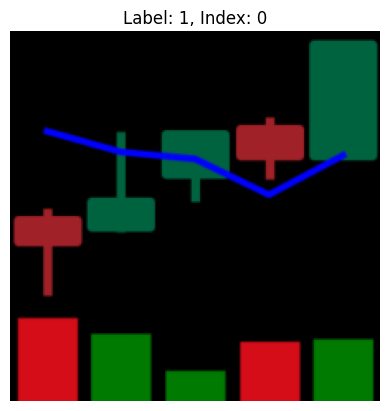

In [8]:
import pandas as pd
from PIL import Image
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

class StockImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label, idx

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = StockImageDataset(train_df, transform=basic_transform)
val_dataset   = StockImageDataset(val_df, transform=basic_transform)
test_dataset  = StockImageDataset(test_df, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Test one batch
images, labels, idx = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

# Show one example image
image, label, idx = train_dataset[0]
img_np = image.permute(1, 2, 0).numpy()

plt.imshow(img_np)
plt.title(f"Label: {label}, Index: {idx}")
plt.axis("off")
plt.show()

Hvis PyTorch bruger CPU i stedet for Nvidia GPU er det fordi du har installeret en CPU version af PyTorch. Så kan man køre følgende kommandoer for at få CUDA version med PyTorch
python -m pip uninstall -y torch torchvision torchaudio
python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [9]:
import torch
import sys

print("Python:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Python: c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe
Torch version: 2.10.0+cu126
CUDA available: True
Torch CUDA version: 12.6
GPU count: 1
GPU name: NVIDIA GeForce RTX 4070


In [10]:
import os
import torch
import torch.nn as nn


class JiangI5RGB(nn.Module):
    """
    Jiang-inspired CNN adapted to your exact use case:
    - only I5 (5 lookback days)
    - predicts 5 days ahead (R5)
    - input images are 224x224 RGB, like in your supervisor's setup

    Important thesis note:
    This is NOT an exact line-by-line copy of Jiang.
    It is a Jiang-style adaptation for your RGB image pipeline.
    """

    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            # ============================================================
            # BLOCK 1
            # ============================================================

            nn.Conv2d(
                in_channels=3,
                # MODIFIED FROM JIANG:
                # Jiang's original images are black/white and effectively 2D sparse chart images.
                # Your images are RGB, so we must use 3 input channels.
                out_channels=32,
                # MODIFIED FROM JIANG:
                # Jiang starts with 64 filters in the first block for the I5 model.
                # I reduce this to 32 to make training lighter and faster for your thesis.
                kernel_size=(5, 3),
                # DIRECTLY FROM JIANG:
                # Jiang uses 5x3 convolution filters because the chart images are sparse
                # in the vertical dimension.
                stride=(1, 1),
                # MODIFIED FROM JIANG:
                # Jiang uses special first-layer vertical stride/dilation settings
                # for sparse raw images.
                # Because your images are already rendered 224x224 RGB charts,
                # I keep standard stride=(1,1) for a simpler and more stable implementation.
                padding=(2, 1),
                # NOT SPECIFICALLY FROM JIANG:
                # This padding keeps output size roughly stable before pooling.
                bias=False
                # NOT SPECIFICALLY FROM JIANG:
                # When BatchNorm comes right after Conv, bias is usually unnecessary.
            ),

            nn.BatchNorm2d(32),
            # DIRECTLY FROM JIANG:
            # Jiang states that batch normalization is applied between
            # convolution and nonlinear activation.

            nn.LeakyReLU(negative_slope=0.01, inplace=True),
            # DIRECTLY FROM JIANG:
            # Jiang explicitly uses leaky ReLU as the activation.

            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
            # DIRECTLY FROM JIANG:
            # Jiang uses 2x1 max-pooling because of the image structure.

            # ============================================================
            # BLOCK 2
            # ============================================================

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                # MODIFIED FROM JIANG:
                # Jiang doubles filters by layer and would go 64 -> 128 for I5.
                # Here I go 32 -> 64 to keep the model lighter.
                kernel_size=(5, 3),
                # DIRECTLY FROM JIANG:
                # Same 5x3 convolution choice as Jiang.
                stride=(1, 1),
                # MODIFIED / PRACTICAL:
                # Again, standard stride rather than Jiang's sparse-first-layer trick.
                padding=(2, 1),
                bias=False
            ),

            nn.BatchNorm2d(64),
            # DIRECTLY FROM JIANG

            nn.LeakyReLU(negative_slope=0.01, inplace=True),
            # DIRECTLY FROM JIANG

            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
            # DIRECTLY FROM JIANG
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            # MODIFIED FROM JIANG:
            # Jiang's original model flattens the final feature map directly
            # and then uses a fully connected layer.
            #
            # I replace that with AdaptiveAvgPool2d((1,1)) because your 224x224 RGB
            # images would otherwise create a much larger classifier head.
            # This keeps training cheaper and cleaner while preserving the CNN logic.

            nn.Flatten(),
            # PARTLY JIANG-LIKE:
            # Jiang also flattens before the final classifier,
            # but here flatten happens after adaptive pooling.

            nn.Dropout(0.5),
            # DIRECTLY FROM JIANG:
            # Jiang uses 50% dropout on the fully connected layer.

            nn.Linear(64, num_classes)
            # MODIFIED FROM JIANG:
            # Jiang's final FC input is much larger because he flattens the whole
            # final CNN output. Here the input is only 64 because of adaptive pooling.
            #
            # num_classes=2 matches your binary Up/Down setup.
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_uniform_(m.weight)
                # DIRECTLY FROM JIANG:
                # Jiang uses Xavier initialization.
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
                    # PRACTICAL CHOICE:
                    # Zero bias init is standard and harmless here.

    def forward(self, x):
        x = self.features(x)
        # Pass image through the 2 Jiang-style CNN blocks.

        x = self.classifier(x)
        # Convert learned feature maps into final Up/Down class scores.

        return x
        # Return raw logits.
        # CrossEntropyLoss will apply the proper classification logic internally.


def count_parameters(model):
    # NOT FROM JIANG:
    # This is just a helper so you can see how large the model is.
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    # NOT FROM JIANG:
    # Standard PyTorch training function.
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    # NOT FROM JIANG:
    # Standard PyTorch evaluation function.
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = JiangI5RGB(num_classes=2).to(device)
print("Trainable params:", count_parameters(model))

criterion = nn.CrossEntropyLoss()
# DIRECTLY FROM JIANG:
# Jiang treats this as a binary classification problem and uses cross-entropy loss.

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# PARTLY FROM JIANG, PARTLY MODIFIED:
# Adam is directly from Jiang.
# The learning rate is MODIFIED.
# Jiang uses 1e-5, but here I use 1e-4 because this is a lighter adapted model
# and in practice that is often easier to train with your setup.
# If training is unstable, try 1e-5.

num_epochs = 15
# MODIFIED / PRACTICAL:
# Jiang uses early stopping, so the exact epoch count is less important.
# 15 is just a reasonable upper limit.

best_val_loss = float("inf")

patience = 3
# MODIFIED FROM JIANG:
# Jiang stops after 2 consecutive non-improving epochs.
# I use 3 to make training a bit less sensitive to noisy validation loss.

patience_counter = 0

model_save_path = os.path.join(data_folder, "best_cnn_i5_rgb_jiang.pth")
# NOT FROM JIANG:
# Just your local save path and filename.

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print("  Saved best model.")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  Early stopping triggered.")
            break
            # DIRECTLY JIANG-LIKE IDEA, MODIFIED IMPLEMENTATION:
            # Jiang uses early stopping after 2 bad epochs.
            # Here we do the same idea, but with patience=3.

Using device: cuda
Trainable params: 32482
Epoch 1/15
  Train loss: 0.8521 | Train acc: 0.4720
  Val   loss: 1.0457 | Val   acc: 0.4387
  Saved best model.
Epoch 2/15
  Train loss: 0.7522 | Train acc: 0.4947
  Val   loss: 0.7615 | Val   acc: 0.4387
  Saved best model.
Epoch 3/15
  Train loss: 0.7412 | Train acc: 0.5142
  Val   loss: 0.6973 | Val   acc: 0.5033
  Saved best model.
Epoch 4/15
  Train loss: 0.7355 | Train acc: 0.5240
  Val   loss: 0.6952 | Val   acc: 0.5165
  Saved best model.
Epoch 5/15
  Train loss: 0.7189 | Train acc: 0.5294
  Val   loss: 0.6938 | Val   acc: 0.5204
  Saved best model.
Epoch 6/15
  Train loss: 0.7352 | Train acc: 0.5085
  Val   loss: 0.6934 | Val   acc: 0.5257
  Saved best model.
Epoch 7/15
  Train loss: 0.7354 | Train acc: 0.5045
  Val   loss: 0.6933 | Val   acc: 0.5296
  Saved best model.
Epoch 8/15
  Train loss: 0.7252 | Train acc: 0.5085
  Val   loss: 0.6949 | Val   acc: 0.5204
Epoch 9/15
  Train loss: 0.7202 | Train acc: 0.5248
  Val   loss: 0.6935 

In [11]:
import os
import torch
import torch.nn.functional as F

# Load best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = JiangI5RGB(num_classes=2).to(device)
model_save_path = os.path.join(data_folder, "best_cnn_i5_rgb_jiang.pth")
model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc:  {test_acc:.4f}")

model.eval()

# Reset index so dataset idx matches dataframe row
test_df = test_df.reset_index(drop=True)

# Create empty column for predicted probability of "up"
test_df["pred_prob_up"] = None

with torch.no_grad():
    for images, labels, indices in test_loader:
        images = images.to(device)

        outputs = model(images)

        # Option A: convert 2 logits to probabilities
        probs_up = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()

        for i, idx in enumerate(indices.numpy()):
            test_df.loc[idx, "pred_prob_up"] = float(probs_up[i])

# Optional: also create predicted class from 0.5 threshold
test_df["pred_label"] = (test_df["pred_prob_up"].astype(float) >= 0.5).astype(int)

# Save file
predictions_path = os.path.join(data_folder, "test_predictions.csv")
test_df.to_csv(predictions_path, index=False)

print("Saved predictions to:", predictions_path)
print(test_df.head())

Test loss: 0.6858
Test acc:  0.5371
Saved predictions to: vol_1_ma_1_bb_0_rsi_0\test_predictions.csv
                                          image_path ticker start_date  \
0  vol_1_ma_1_bb_0_rsi_0\PGR\PGR_2024-03-21_to_20...    PGR 2024-03-21   
1  vol_1_ma_1_bb_0_rsi_0\TJX\TJX_2024-03-26_to_20...    TJX 2024-03-26   
2  vol_1_ma_1_bb_0_rsi_0\VTV\VTV_2024-03-26_to_20...    VTV 2024-03-26   
3  vol_1_ma_1_bb_0_rsi_0\ANET\ANET_2024-03-26_to_...   ANET 2024-03-26   
4  vol_1_ma_1_bb_0_rsi_0\SCHW\SCHW_2024-03-26_to_...   SCHW 2024-03-26   

    end_date  close_now  close_future  label       date  file_exists  \
0 2024-03-27     206.15        209.24      1 2024-03-27         True   
1 2024-04-02      99.47         97.10      0 2024-04-02         True   
2 2024-04-02     161.18        160.80      0 2024-04-02         True   
3 2024-04-02     290.85        294.75      1 2024-04-02         True   
4 2024-04-02      71.46         72.28      1 2024-04-02         True   

  pred_prob_up  pred_

In [12]:
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, confusion_matrix

y = test_df["label"].to_numpy()
p = test_df["pred_prob_up"].astype(float).to_numpy()
pred = (p >= 0.5).astype(int)

print("Pred prob summary:")
print("min =", p.min())
print("max =", p.max())
print("mean =", p.mean())
print("share below 0.5 =", np.mean(p < 0.5))
print("share above/equal 0.5 =", np.mean(p >= 0.5))

print("\nClassification metrics:")
print("Accuracy         =", accuracy_score(y, pred))
print("Balanced accuracy=", balanced_accuracy_score(y, pred))
print("AUC              =", roc_auc_score(y, p))
print("Log loss         =", log_loss(y, p))
print("\nConfusion matrix:")
print(confusion_matrix(y, pred))

Pred prob summary:
min = 0.48398059606552124
max = 0.6204895377159119
mean = 0.5483367073873759
share below 0.5 = 0.03508771929824561
share above/equal 0.5 = 0.9649122807017544

Classification metrics:
Accuracy         = 0.5371120107962213
Balanced accuracy= 0.502618779026327
AUC              = 0.5690844895029081
Log loss         = 0.6858073633046728

Confusion matrix:
[[ 13 330]
 [ 13 385]]


In [13]:
base_p = train_df["label"].mean()
base_pred_prob = np.full_like(y, fill_value=base_p, dtype=float)
base_pred_class = np.ones_like(y) if base_p >= 0.5 else np.zeros_like(y)

print("Baseline constant prob =", base_p)
print("Baseline accuracy      =", (y == base_pred_class).mean())
print("Baseline log loss      =", log_loss(y, base_pred_prob))

Baseline constant prob = 0.5481183567940247
Baseline accuracy      = 0.5371120107962213
Baseline log loss      = 0.6906342591363168
